# 🏆 FIFA World Cup 2026 – AI Match Prediction Model
### YouTube Tutorial Notebook

**What we build in this notebook:**
1. Load 130+ years of international match data (free, no API key)
2. Build a dynamic Elo rating system to rank every national team
3. Engineer features: form, head-to-head, tournament context
4. Train an XGBoost classifier to predict Home Win / Draw / Away Win
5. Generate expected goals (xG) estimates
6. Run a Monte Carlo tournament simulation
7. Export YouTube-ready charts

---


## 0. Setup

In [1]:
"""
"" checking path by Mir
import os

print("Current directory:")
print(os.getcwd())

print("\nRoot directory:")
print(os.path.abspath(os.sep))
"""

'\n"" checking path by Mir\nimport os\n\nprint("Current directory:")\nprint(os.getcwd())\n\nprint("\nRoot directory:")\nprint(os.path.abspath(os.sep))\n'

In [1]:
# Fix: install using THIS notebook's Python (not terminal Python)
import sys
print("Python being used:", sys.executable)

import subprocess
subprocess.run([sys.executable, "-m", "pip", "install",
                "xgboost", "scikit-learn", "numpy",
                "pandas", "matplotlib", "requests",
                "--quiet"], check=True)

print("✅ All packages installed into the correct Python")

Python being used: C:\ProgramData\anaconda3\python.exe
✅ All packages installed into the correct Python


In [2]:
# Run once in terminal: pip install -r requirements.txt
import sys
sys.path.insert(0, '..')  # if running from a subdirectory

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Import our custom modules
from predictor import (
    load_results, EloRatingSystem, build_features,
    train_model, predict_match, print_prediction,
    plot_match_prediction, plot_elo_rankings,
    simulate_tournament, plot_championship_probs,
    WC2026_MATCHES, COLORS, VIS_DIR
)

print('✅ All imports OK')

✅ All imports OK


## 1. Load Data (free, no API key required)

In [3]:
df = load_results()
print(f'\n📅 Date range: {df["date"].min().date()} → {df["date"].max().date()}')
df.tail(5)

📂  Loading cached match history …
    Dropped 72 rows with missing scores.
    32,174 matches loaded (1990–present).

📅 Date range: 1990-01-12 → 2026-06-01


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49286,2026-06-01,Colombia,Costa Rica,3,1,Friendly,Bogota,Colombia,False
49287,2026-06-01,Norway,Sweden,3,1,Friendly,Oslo,Norway,False
49288,2026-06-01,Slovakia,Malta,2,1,Friendly,Dunajská Streda,Slovakia,False
49289,2026-06-01,Turkey,North Macedonia,4,0,Friendly,Istanbul,Turkey,False
49290,2026-06-01,Maldives,Afghanistan,0,1,Diamond Jubilee International Football Tournament,Malé,Maldives,False


## 2. Build Elo Ratings

In [4]:
elo = EloRatingSystem().fit(df)
top20 = elo.top_n(20)
print('\n🏅 Top 20 teams by Elo rating:')
print(top20.to_string(index=False))


🏅 Top 20 teams by Elo rating:
       team         elo
      Spain 2285.656866
  Argentina 2244.697847
     France 2227.455871
    England 2200.924382
     Brazil 2155.467316
   Colombia 2130.223300
      Japan 2098.283504
Netherlands 2092.761674
    Ecuador 2091.743645
    Morocco 2059.175607
     Norway 2051.866419
    Croatia 2046.452534
    Uruguay 2042.096922
    Germany 2036.904058
    Belgium 2033.935101
Switzerland 2030.917108
   Portugal 2019.502331
   Paraguay 1990.038689
South Korea 1987.486537
    Senegal 1982.016796


In [5]:
# Save the rankings chart for YouTube
plot_elo_rankings(elo, save_path=VIS_DIR / 'elo_rankings.png', top_n=20)

    📸 Rankings chart saved → C:\Users\Mir\Goa_IQ_Lab\visuals\elo_rankings.png


## 3. Feature Engineering

In [6]:
feat_df = build_features(df, elo)
feat_df[['home_team','away_team','elo_diff','form_diff','h2h_home_winrate','outcome']].tail(8)

⚙️   Engineering features …
    Feature matrix: (32174, 17)


,home_team,away_team,elo_diff,form_diff,h2h_home_winrate,outcome
32166,Norway,Sweden,390.566325,3.8,0.400000,2
32167,Slovakia,Malta,588.740012,2.8,0.800000,2
32168,Colombia,Costa Rica,465.186730,1.0,0.900000,2
32169,Turkey,North Macedonia,449.778437,2.4,0.625000,2
32170,Bulgaria,Montenegro,197.710493,0.4,0.125000,0
32171,Austria,Tunisia,160.251219,3.2,0.500000,2
32172,Canada,Uzbekistan,146.950477,0.4,1.000000,2
32173,Maldives,Afghanistan,-88.940476,1.0,0.333333,0


## 4. Train the Model

In [7]:
model = train_model(feat_df)

🤖  Training XGBoost classifier …
    CV accuracy: 0.579 ± 0.002

    Training set report:
              precision    recall  f1-score   support

    Away win       0.56      0.60      0.58      9017
        Draw       0.63      0.04      0.08      7561
    Home win       0.62      0.87      0.72     15596

    accuracy                           0.60     32174
   macro avg       0.60      0.50      0.46     32174
weighted avg       0.60      0.60      0.53     32174



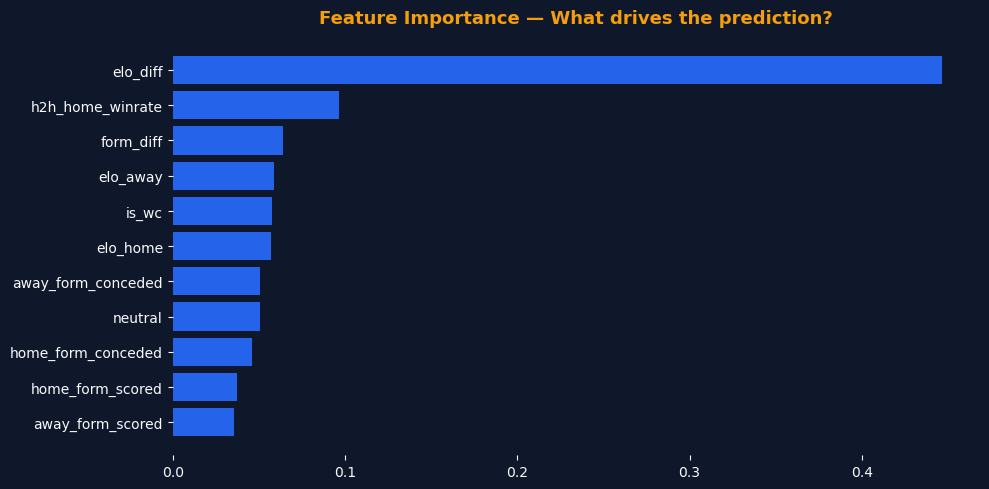

In [8]:
# Feature importance – great for a 'how does it work' YouTube segment
import xgboost as xgb
from predictor import FEATURE_COLS

fig, ax = plt.subplots(figsize=(10, 5), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

importances = model.feature_importances_
idx = np.argsort(importances)

ax.barh([FEATURE_COLS[i] for i in idx], importances[idx],
        color=COLORS['home'], edgecolor='none')
ax.tick_params(colors=COLORS['text'])
ax.spines[:].set_visible(False)
ax.set_title('Feature Importance — What drives the prediction?',
             color=COLORS['accent'], fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(VIS_DIR / 'feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()

## 5. Predict Group-Stage Matches

In [9]:
# ⭐ Change these to any upcoming WC26 match!
HOME_TEAM = 'Mexico'
AWAY_TEAM = 'South Africa'

pred = predict_match(HOME_TEAM, AWAY_TEAM, elo, model, feat_df)
print_prediction(pred)

# Save chart → use in video thumbnail
plot_match_prediction(
    pred,
    save_path=VIS_DIR / f'pred_{HOME_TEAM.lower()}_{AWAY_TEAM.lower()}.png'
)


  ⚽            Mexico  vs  South Africa    
  ────────────────────────────────────────────────────
  Home win     █████████████████████████████             73.1%  (Elo 1980)
  Draw         ████████                                  20.8%
  Away win     ██                                         6.1%  (Elo 1664)
  ────────────────────────────────────────────────────
  xG: Mexico 2.87 – 0.61 South Africa
  🏅  Favorite: Mexico
    📸 Chart saved → C:\Users\Mir\Goa_IQ_Lab\visuals\pred_mexico_south africa.png


In [10]:
# Predict ALL WC26 group stage matches (batch mode)
results = []
for home, away, date in WC2026_MATCHES:
    p = predict_match(home, away, elo, model, feat_df)
    p['date'] = date
    results.append(p)

predictions_df = pd.DataFrame(results)[[
    'date','home','away','p_home','p_draw','p_away','xg_home','xg_away','favorite'
]]
predictions_df.to_csv(VIS_DIR / 'group_stage_predictions.csv', index=False)
print('\n💾 Predictions saved!')
predictions_df


💾 Predictions saved!


,date,home,away,p_home,p_draw,p_away,xg_home,xg_away,favorite
0,2026-06-11,Mexico,South Africa,0.731,0.208,0.061,2.87,0.61,Mexico
1,2026-06-11,South Korea,Czechia,0.866,0.102,0.031,4.68,0.41,South Korea
2,2026-06-17,Mexico,Czechia,0.875,0.095,0.030,4.58,0.53,Mexico
3,2026-06-17,South Korea,South Africa,0.731,0.201,0.068,2.93,0.48,South Korea
4,2026-06-22,Mexico,South Korea,0.376,0.288,0.337,1.25,1.41,Mexico
...,...,...,...,...,...,...,...,...,...
67,2026-06-17,Ghana,Panama,0.235,0.235,0.530,0.30,1.28,Panama
68,2026-06-23,England,Ghana,0.802,0.141,0.056,5.65,0.31,England
69,2026-06-23,Croatia,Panama,0.592,0.237,0.171,2.76,0.60,Croatia
70,2026-06-27,England,Panama,0.742,0.180,0.078,3.58,0.57,England


## 6. Tournament Simulation

In [12]:
import numpy as np
import pandas as pd
from collections import defaultdict
import gc, pathlib

print("🏆 Running 10,000 tournament simulations (fixed version)...")
print("   Progress: ", end="", flush=True)

rng = np.random.default_rng(42)
VIS_DIR = pathlib.Path("visuals")
VIS_DIR.mkdir(exist_ok=True)

# ── Get top 32 teams by current Elo ─────────────────────────
top_teams = (
    pd.DataFrame(elo.ratings.items(), columns=["team", "elo"])
    .sort_values("elo", ascending=False)
    .head(32)["team"]
    .tolist()
)

# ── Pre-compute form for all teams once ─────────────────────
W = 5
form_cache = {}
for team in top_teams:
    rows = feat_df[
        (feat_df["home_team"] == team) | (feat_df["away_team"] == team)
    ].tail(W * 2)
    sc, cc = [], []
    for _, r in rows.iterrows():
        if r["home_team"] == team:
            sc.append(r["home_score"]); cc.append(r["away_score"])
        else:
            sc.append(r["away_score"]); cc.append(r["home_score"])
    form_cache[team] = (
        float(np.mean(sc[-W:])) if sc else 1.5,
        float(np.mean(cc[-W:])) if cc else 1.2,
    )

# ── Pre-compute h2h from feat_df ────────────────────────────
h2h_map = defaultdict(list)
for _, r in feat_df.iterrows():
    h, a = r["home_team"], r["away_team"]
    gh, ga = int(r["home_score"]), int(r["away_score"])
    key = tuple(sorted([h, a]))
    winner = h if gh > ga else (a if ga > gh else "draw")
    h2h_map[key].append(winner)

FEAT_COLS = [
    "elo_diff", "elo_home", "elo_away", "neutral", "is_wc",
    "home_form_scored", "home_form_conceded",
    "away_form_scored", "away_form_conceded",
    "form_diff", "h2h_home_winrate",
]
INITIAL = 1500

# ── Fast win-probability function ───────────────────────────
def win_prob(home, away):
    elo_h = elo.ratings.get(home, INITIAL)
    elo_a = elo.ratings.get(away, INITIAL)
    h_sc, h_cc = form_cache.get(home, (1.5, 1.2))
    a_sc, a_cc = form_cache.get(away, (1.5, 1.2))
    key  = tuple(sorted([home, away]))
    past = h2h_map.get(key, [])[-10:]
    h2h  = sum(1 for x in past if x == home) / len(past) if past else 0.5
    X = pd.DataFrame([{
        "elo_diff":      elo_h - elo_a,
        "elo_home":      elo_h,
        "elo_away":      elo_a,
        "neutral":       1,
        "is_wc":         1,
        "home_form_scored":   h_sc,
        "home_form_conceded": h_cc,
        "away_form_scored":   a_sc,
        "away_form_conceded": a_cc,
        "form_diff":     (h_sc - h_cc) - (a_sc - a_cc),
        "h2h_home_winrate": h2h,
    }])
    probs = model.predict_proba(X[FEAT_COLS])[0]
    # [away, draw, home] — draws → 50/50 penalties in knockout
    return float(probs[2]) + float(probs[1]) * 0.5

# ── Simulate one complete tournament ────────────────────────
def simulate_one():
    remaining = list(top_teams)
    rng.shuffle(remaining)
    # Max 6 rounds covers 32→16→8→4→2→1
    for _ in range(6):
        if len(remaining) <= 1:
            break
        next_round = []
        # Pair up teams — odd team gets a bye
        for i in range(0, len(remaining) - 1, 2):
            h, a = remaining[i], remaining[i + 1]
            p = win_prob(h, a)
            next_round.append(h if rng.random() < p else a)
        if len(remaining) % 2 == 1:
            next_round.append(remaining[-1])
        remaining = next_round
    return remaining[0]

# ── Run 10,000 simulations ───────────────────────────────────
N_SIMS = 10_000
wins = defaultdict(int)

for i in range(N_SIMS):
    wins[simulate_one()] += 1
    if (i + 1) % 1000 == 0:
        print(f"{i+1}", end=" ", flush=True)

gc.collect()
print(f"\n✅ {N_SIMS:,} simulations complete!\n")

# ── Build results table ──────────────────────────────────────
sim_results = (
    pd.DataFrame([
        {"team": t, "championship_prob": round(wins.get(t, 0) / N_SIMS * 100, 2)}
        for t in top_teams
    ])
    .sort_values("championship_prob", ascending=False)
    .reset_index(drop=True)
)
sim_results.index += 1

print("🏆 Championship Probabilities:\n")
print(sim_results.head(15).to_string(index=True))

# ── Save CSV ─────────────────────────────────────────────────
sim_results.to_csv(VIS_DIR / "championship_probs.csv")
print(f"\n✅ Saved → visuals/championship_probs.csv")

# ── Save chart ───────────────────────────────────────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

NAVY="#0D1B2A"; AMBER="#E8A020"; BLUE="#2563EB"; WHITE="#F5F0E8"
top12 = sim_results.head(12)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=NAVY)
ax.set_facecolor(NAVY)
colors = [AMBER if i==0 else "#94A3B8" if i<3 else BLUE for i in range(len(top12))]
bars = ax.bar(top12["team"], top12["championship_prob"],
              color=colors, edgecolor="none", width=0.6)
for bar, (_, row) in zip(bars, top12.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.12,
            f"{row['championship_prob']:.1f}%",
            ha="center", color=WHITE, fontsize=9, fontweight="bold")
ax.set_ylabel("Championship probability (%)", color=WHITE, fontsize=10)
ax.tick_params(colors=WHITE, labelsize=9)
ax.spines[:].set_visible(False)
plt.xticks(rotation=28, ha="right")
ax.set_ylim(0, top12["championship_prob"].max() * 1.18)
ax.set_title("Who Wins World Cup 2026? — Goal IQ Lab (10,000 simulations)",
             color=AMBER, fontsize=12, fontweight="bold", pad=12)
p1 = mpatches.Patch(color=AMBER,    label=f"🥇 {top12.iloc[0]['team']}")
p2 = mpatches.Patch(color="#94A3B8",label="Top 3")
p3 = mpatches.Patch(color=BLUE,     label="Top 12")
ax.legend(handles=[p1,p2,p3], facecolor=NAVY, labelcolor=WHITE, fontsize=9)
plt.tight_layout()
out = VIS_DIR / "championship_probs.png"
fig.savefig(out, dpi=150, bbox_inches="tight", facecolor=NAVY)
plt.close(fig)
gc.collect()
print(f"✅ Chart saved → {out}")

🏆 Running 10,000 tournament simulations (fixed version)...
   Progress: 1000 2000 3000 4000 5000 6000 7000 8000 9000 10000 
✅ 10,000 simulations complete!

🏆 Championship Probabilities:

           team  championship_prob
1     Argentina              15.63
2         Spain              13.12
3        France              11.71
4       England               7.13
5        Brazil               6.17
6      Colombia               4.31
7       Germany               4.20
8   Netherlands               4.03
9       Belgium               3.70
10        Japan               3.54
11      Ecuador               3.52
12      Morocco               2.99
13       Norway               2.66
14      Croatia               2.39
15      Uruguay               1.94

✅ Saved → visuals/championship_probs.csv
✅ Chart saved → visuals\championship_probs.png


## 7. Next Steps for Your YouTube Channel

| Video idea | What to show | Code section |
|---|---|---|
| Pre-match preview | `plot_match_prediction()` chart | Section 5 |
| Power rankings | `plot_elo_rankings()` chart | Section 2 |
| 'Who wins WC26?' | `plot_championship_probs()` | Section 6 |
| Tutorial: build xG model | Walk through feature_engineering | Section 3 |
| Post-match: was AI right? | Compare pred vs actual score | Section 5 |

**Live data upgrade:** When the tournament starts, replace `load_results()` with
live data from the free [BALLDONTLIE FIFA API](https://fifa.balldontlie.io/) or
[openfootball JSON](https://github.com/openfootball/worldcup.json).
